# 06 · Multi-head attention — many views at once

One attention is a single perspective. Real Transformers run several **heads in parallel**
(GPT-3: 96). Each head gets its own Q/K/V projections and can specialise — one tracks grammar,
one subject–verb links, one long-range meaning. Split the vector into `h` chunks, attend in
each independently, concatenate, then mix with an output projection `Wo`.

In [1]:
import numpy as np
np.random.seed(0)
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True); e = np.exp(x); return e / e.sum(axis=axis, keepdims=True)
def attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    s = Q @ K.swapaxes(-1, -2) / np.sqrt(d_k)
    if mask is not None: s = np.where(mask, s, -1e9)
    w = softmax(s, axis=-1); return w @ V, w

def multi_head_attention(Xin, n_heads, mask=None):
    T, d = Xin.shape
    dh = d // n_heads                                  # each head works in a d/h subspace
    Wq, Wk, Wv, Wo = (np.random.randn(d, d) for _ in range(4))
    Q, K, V = Xin @ Wq, Xin @ Wk, Xin @ Wv
    split = lambda M: M.reshape(T, n_heads, dh).transpose(1, 0, 2)   # (T,d) -> (h,T,dh)
    Qh, Kh, Vh = split(Q), split(K), split(V)
    per_head = [attention(Qh[i], Kh[i], Vh[i], mask) for i in range(n_heads)]
    concat = np.concatenate([o for o, _ in per_head], axis=-1)       # (T, d) again
    return concat @ Wo, [w for _, w in per_head]

T, d = 5, 8
X = np.random.randn(T, d)
causal = np.tril(np.ones((T, T))).astype(bool)
out, head_weights = multi_head_attention(X, n_heads=4, mask=causal)
print("output shape:", out.shape, "(same as input -> blocks stack cleanly)")
assert out.shape == X.shape
print("num heads:", len(head_weights), "each a", head_weights[0].shape, "weight matrix")

output shape: (5, 8) (same as input -> blocks stack cleanly)
num heads: 4 each a (5, 5) weight matrix


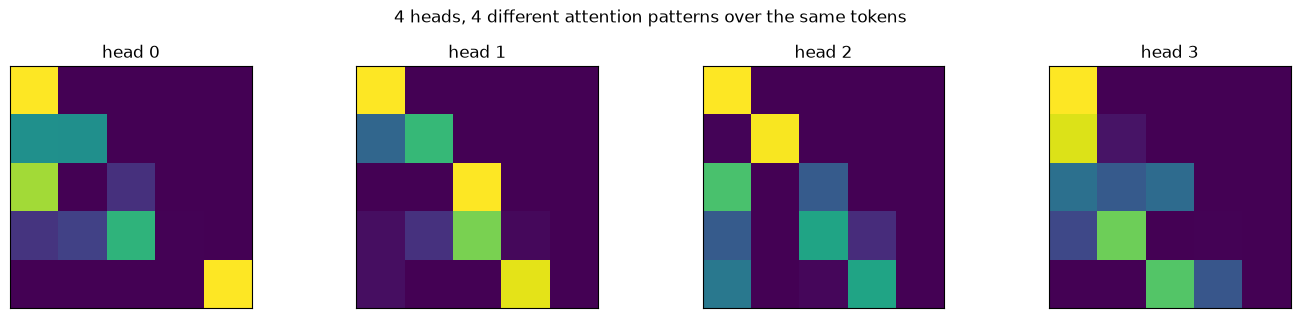

In [2]:
# Visual: different heads attend differently (even from random init).
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for h, ax in enumerate(axes):
    im = ax.imshow(head_weights[h], cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"head {h}"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("4 heads, 4 different attention patterns over the same tokens")
plt.tight_layout(); plt.show()

**Takeaway.** Multi-head = run attention `h` times in parallel subspaces and combine. More
heads = more relationship types captured at once, at the same total compute. Next:
**07 · feed-forward**.